#  Redes de Kolmogorov-Arnold (KAN)
## Implementación desde `nn.Module` — PyTorch

---

| Bloque | Contenido |
|--------|----------|
| 1 | Bases B-Spline — Recursión de de Boor |
| 2 | `KANLayer` — capa con activaciones aprendibles en aristas |
| 3 | `KAN` — red completa con conteo de parámetros |
| 4 | Entrenamiento clasificación 2D: Make Moons |
| 5 | Visualización: frontera de decisión + φ(x) + curvas |

### Fórmulas implementadas

| Fórmula | Nombre |
|---------|--------|
| $f(x_1,...,x_n) = \sum_q \Phi_q\bigl(\sum_p \phi_{q,p}(x_p)\bigr)$ | Teorema K-A |
| $\text{KAN}(x) = (\Phi_{L-1} \circ \cdots \circ \Phi_0)\,x$ | Red profunda |
| $x_{\ell+1,j} = \sum_i \phi_{\ell,j,i}(x_{\ell,i})$ | Forward pass |
| $\phi(x) = w_b \cdot \text{SiLU}(x) + w_s \cdot \sum_i c_i B_{i,k}(x)$ | Activación aprendible |
| $\mathcal{L} = \mathcal{L}_{\text{BCE}} + \lambda\,\|\phi\|_1$ | Pérdida regularizada |

##  Bloque 0 — Instalación e imports

In [8]:
# Solo necesario la primera vez (en Colab ya están instalados)
# !pip install torch scikit-learn matplotlib -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch: {torch.__version__}')
print(f'Dispositivo: {"CUDA" if torch.cuda.is_available() else "CPU"}')

PyTorch: 2.5.1+cu121
Dispositivo: CUDA


---
## Bloque 1 — Bases B-Spline (Recursión de de Boor)

Las B-Splines son el **núcleo** de KAN. Cada función de activación φ(x) en una arista
se representa como combinación lineal de bases B-Spline:

$$\text{spline}(x) = \sum_{i=0}^{G+k-1} c_i \cdot B_{i,k}(x)$$

Las bases $B_{i,k}$ se construyen con la **recursión de de Boor**:

**Caso base (orden 0):**
$$B_{i,0}(x) = \begin{cases} 1 & t_i \leq x < t_{i+1} \\ 0 & \text{en otro caso} \end{cases}$$

**Recursión (orden k):**
$$B_{i,k}(x) = \frac{x - t_i}{t_{i+k} - t_i}\,B_{i,k-1}(x) + \frac{t_{i+k+1} - x}{t_{i+k+1} - t_{i+1}}\,B_{i+1,k-1}(x)$$

Con **G intervalos** y orden **k**, se obtienen **G+k funciones base** sobre **G+2k+1 nodos**.

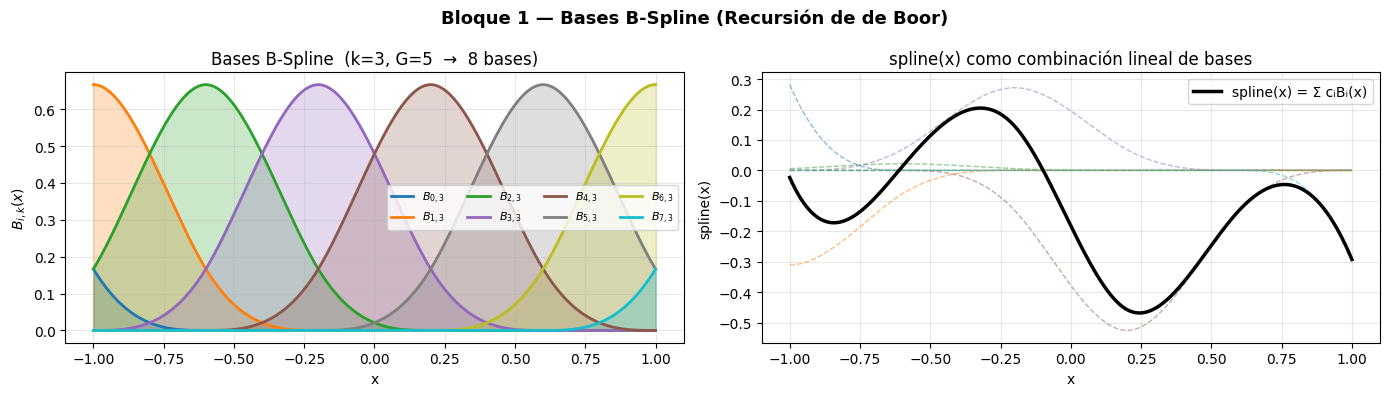

Grid: 12 nodos  |  Bases: G+k = 8


In [9]:
def build_bspline_bases(x: torch.Tensor,
                        grid: torch.Tensor,
                        k: int = 3) -> torch.Tensor:
    """
    Bases B-Spline via recursión de de Boor (sin librerías externas).

    Parámetros
    ----------
    x    : (batch,)       — valores de entrada
    grid : (G+2k+1,)      — nodos del grid extendido (con clamping)
    k    : int            — orden del spline (k=3 → cúbico)

    Retorna
    -------
    bases : (batch, G+k)  — una columna por función base B_{i,k}
    """
    x = x.unsqueeze(1)                                      # (batch, 1)

    # ── CASO BASE: orden 0 ─────────────────────────────────────────────
    # B_{i,0}(x) = 1  si  t_i <= x < t_{i+1},  0 en otro caso
    bases = ((x >= grid[:-1]) & (x < grid[1:])).float()    # (batch, G+2k)

    # ── RECURSIÓN: de orden 1 hasta orden k ───────────────────────────
    for order in range(1, k + 1):
        # Numeradores y denominadores según la fórmula
        left_num  = x              - grid[:-(order + 1)]    # x  - t_i
        left_den  = grid[order:-1] - grid[:-(order + 1)]    # t_{i+k} - t_i

        right_num = grid[(order + 1):] - x                  # t_{i+k+1} - x
        right_den = grid[(order + 1):] - grid[1:-order]     # t_{i+k+1} - t_{i+1}

        # División segura: 0/0 → 0  (convención estándar en B-Splines)
        left  = torch.where(left_den  != 0,
                            left_num  / left_den,
                            torch.zeros_like(left_num))
        right = torch.where(right_den != 0,
                            right_num / right_den,
                            torch.zeros_like(right_num))

        # Combinar con las bases del orden anterior
        bases = left * bases[:, :-1] + right * bases[:, 1:]

    return bases   # (batch, G+k)


# ── Visualización de bases B-Spline cúbicas ───────────────────────────
G_demo, k_demo = 5, 3
grid_demo  = torch.linspace(-1, 1, G_demo + 1)
step_demo  = 2.0 / G_demo
left_ext   = grid_demo[0]  - step_demo * torch.arange(k_demo, 0, -1)
right_ext  = grid_demo[-1] + step_demo * torch.arange(1, k_demo + 1)
grid_demo  = torch.cat([left_ext, grid_demo, right_ext])   # G+2k+1 nodos

x_demo   = torch.linspace(-1, 1, 400)
B_demo   = build_bspline_bases(x_demo, grid_demo, k_demo)  # (400, G+k=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Bases individuales
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, B_demo.shape[1]))
for i in range(B_demo.shape[1]):
    ax.fill_between(x_demo.numpy(), B_demo[:, i].numpy(),
                    alpha=0.25, color=colors[i])
    ax.plot(x_demo.numpy(), B_demo[:, i].numpy(),
            color=colors[i], linewidth=2, label=f'$B_{{{i},3}}$')
ax.set_title(f'Bases B-Spline  (k={k_demo}, G={G_demo}  →  {G_demo+k_demo} bases)',
             fontsize=12)
ax.set_xlabel('x'); ax.set_ylabel('$B_{i,k}(x)$')
ax.legend(ncol=4, fontsize=8); ax.grid(alpha=0.3)

# (b) Ejemplo de spline: combinación lineal con coef aleatorios
ax = axes[1]
np.random.seed(7)
coefs = np.random.randn(B_demo.shape[1])
spline_ex = (B_demo.numpy() * coefs).sum(axis=1)
for i in range(B_demo.shape[1]):
    ax.plot(x_demo.numpy(), coefs[i] * B_demo[:, i].numpy(),
            '--', color=colors[i], linewidth=1, alpha=0.5)
ax.plot(x_demo.numpy(), spline_ex, 'k-', linewidth=2.5,
        label='spline(x) = Σ cᵢBᵢ(x)')
ax.set_title('spline(x) como combinación lineal de bases', fontsize=12)
ax.set_xlabel('x'); ax.set_ylabel('spline(x)')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle('Bloque 1 — Bases B-Spline (Recursión de de Boor)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bloque1_bsplines.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Grid: {G_demo+2*k_demo+1} nodos  |  Bases: G+k = {G_demo+k_demo}')

---
##  Bloque 2 — `KANLayer`: Capa con activaciones aprendibles en aristas

Diferencia fundamental con MLP:

| | MLP | KAN |
|---|---|---|
| No-linealidad | Nodos (σ **fija**: ReLU/tanh) | Aristas (φ **aprendible**) |
| Parámetros | Escalares $w_{ij}$ | Funciones $\phi_{ij}(x)$ |
| Forward | $x_{\ell+1} = \sigma(W_\ell x_\ell + b_\ell)$ | $x_{\ell+1,j} = \sum_i \phi_{\ell,j,i}(x_{\ell,i})$ |

**Activación aprendible por arista:**
$$\phi_{j,i}(x) = \underbrace{w_b \cdot \text{SiLU}(x)}_{\text{rama base (residual)}} + \underbrace{w_s \cdot \sum_{i} c_i B_{i,k}(x)}_{\text{rama spline (aprendible)}}$$

**Parámetros aprendibles POR conexión:**
- $w_b, w_s \in \mathbb{R}$ — escalares de ponderación
- $c_i \in \mathbb{R}^{G+k}$ — coeficientes del spline

**Total de parámetros por capa:** $n_{\text{in}} \times n_{\text{out}} \times (G + k + 2)$

In [10]:
class KANLayer(nn.Module):
    """
    Una capa KAN: n_in entradas → n_out salidas.

    Cada una de las n_in × n_out conexiones tiene parámetros propios:
      · w_b  (escalar)      — peso rama base  (SiLU)
      · w_s  (escalar)      — peso rama spline
      · coef (G+k valores)  — coeficientes B-Spline aprendibles

    Fórmula de activación:
      phi(x) = w_b * SiLU(x)  +  w_s * sum_i(c_i * B_{i,k}(x))

    Forward pass:
      x_{ℓ+1, j} = sum_i  phi_{j,i}(x_{ℓ,i})
    """

    def __init__(self,
                 n_in:        int,
                 n_out:       int,
                 G:           int   = 5,
                 k:           int   = 3,
                 grid_range:  tuple = (-1., 1.),
                 noise_scale: float = 0.1):
        super().__init__()

        self.n_in, self.n_out = n_in, n_out
        self.G, self.k = G, k

        # ── Grid extendido: G+1 puntos internos + k en cada extremo ──
        # Estructura: [t_{-k}, ..., t_0, t_1, ..., t_G, ..., t_{G+k}]
        # Total: G + 2k + 1 nodos
        grid_int  = torch.linspace(grid_range[0], grid_range[1], G + 1)
        step      = (grid_range[1] - grid_range[0]) / G
        left_ext  = grid_int[0]  - step * torch.arange(k, 0, -1)
        right_ext = grid_int[-1] + step * torch.arange(1, k + 1)
        grid      = torch.cat([left_ext, grid_int, right_ext])  # (G+2k+1,)

        # El grid NO es parámetro — se registra como buffer (constante entrenamiento)
        self.register_buffer('grid', grid)

        n_bases = G + k   # número de funciones base

        # ── Parámetros aprendibles (todos son nn.Parameter) ───────────
        # Inicialización: w_b=1, w_s=1, coef~N(0, noise_scale²)
        self.w_b  = nn.Parameter(torch.ones(n_out, n_in))
        self.w_s  = nn.Parameter(torch.ones(n_out, n_in))
        self.coef = nn.Parameter(
            torch.randn(n_out, n_in, n_bases) * noise_scale
        )

    # ── Calcula phi_{j,i}(x) para todas las conexiones ────────────────
    def _phi(self, x: torch.Tensor) -> torch.Tensor:
        """
        x      : (batch, n_in)
        return : (batch, n_out, n_in)   ← phi_{j,i}(x_i) para todo j,i
        """
        # Bases para cada dimensión de entrada → (batch, n_in, n_bases)
        bases = torch.stack(
            [build_bspline_bases(x[:, i], self.grid, self.k)
             for i in range(self.n_in)],
            dim=1
        )

        # Rama spline: Σ c_i * B_{i,k}(x)  para cada conexión
        # coef: (n_out, n_in, n_bases)  ×  bases: (batch, n_in, n_bases)
        # → spline_out: (batch, n_out, n_in)
        spline_out = torch.einsum('oji,bji->boj', self.coef, bases)

        # Rama base: SiLU(x)  broadcasteada a (batch, n_out, n_in)
        base_out = F.silu(x).unsqueeze(1).expand(-1, self.n_out, -1)

        # phi(x) = w_b * SiLU(x)  +  w_s * spline(x)
        return self.w_b * base_out + self.w_s * spline_out

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass:  x_{ℓ+1, j} = Σ_i  phi_{j,i}(x_{ℓ,i})

        x      : (batch, n_in)
        return : (batch, n_out)
        """
        phi = self._phi(x)        # (batch, n_out, n_in)
        return phi.sum(dim=-1)    # (batch, n_out)  ← suma sobre todas las entradas

---
##  Bloque 3 — `KAN`: Red completa + Comparativa de parámetros

$$\text{KAN}(x) = (\Phi_{L-1} \circ \Phi_{L-2} \circ \cdots \circ \Phi_1 \circ \Phi_0)\,x$$

Cada $\Phi_\ell$ es una **matriz de funciones** (no de escalares como en MLP):

$$\Phi_\ell = \{\phi_{\ell,j,i}\}_{i=1..n_\ell,\; j=1..n_{\ell+1}}$$

In [11]:
class KAN(nn.Module):
    """
    Red KAN completa.

    Parámetros
    ----------
    widths : lista de anchos, ej: [2, 5, 1]
             → 2 entradas, 5 neuronas ocultas, 1 salida
    G, k   : hiperparámetros del spline
             G = intervalos del grid  (más G → más precisión, más parámetros)
             k = orden del polinomio  (k=3 → spline cúbico)
    """

    def __init__(self, widths: list, G: int = 5, k: int = 3):
        super().__init__()
        self.layers = nn.ModuleList([
            KANLayer(n_in=widths[i], n_out=widths[i + 1], G=G, k=k)
            for i in range(len(widths) - 1)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # KAN(x) = Phi_{L-1}( ... Phi_1( Phi_0(x) ) ...)
        for layer in self.layers:
            x = layer(x)
        return x

    def count_params(self):
        """Tabla comparativa de parámetros por capa vs MLP equivalente."""
        layer = self.layers[0]
        G, k  = layer.G, layer.k

        print(f'\n{"─"*55}')
        print(f'  KAN  widths={[l.n_in for l in self.layers]+[self.layers[-1].n_out]}')
        print(f'  Hiperparámetros spline: G={G}, k={k}')
        print(f'  Parámetros por spline: G+k+2 = {G+k+2}')
        print(f'{"─"*55}')
        print(f'{"Capa":<30} {"KAN params":>12}')
        print(f'{"─"*55}')

        total = 0
        for idx, lyr in enumerate(self.layers):
            n = sum(p.numel() for p in lyr.parameters())
            formula = f'{lyr.n_in}×{lyr.n_out}×({G}+{k}+2)'
            print(f'  Capa {idx}  ({lyr.n_in}→{lyr.n_out})  {formula:<15} {n:>8,}')
            total += n

        print(f'{"─"*55}')
        print(f'  {"TOTAL KAN":<28} {total:>12,}')
        print(f'{"─"*55}\n')


# ── Instanciar y mostrar arquitectura ────────────────────────────────
model = KAN(widths=[2, 5, 1], G=5, k=3)
model.count_params()

# Comparación directa en tabla
print('Comparación de parámetros KAN vs MLP:')
print(f'{"Arquitectura":<30} {"Parámetros":>12} {"Observación"}')
print('─' * 65)
configs = [
    ('MLP [2, 10, 1]',        2*10+10 + 10*1+1,  'Referencia base'),
    ('KAN [2, 5, 1] G=5 k=3', 2*5*10  + 5*1*10,  'Más expresividad'),
    ('KAN [2, 1, 1] G=5 k=3', 2*1*10  + 1*1*10,  'Comparable al MLP'),
]
for name, n, obs in configs:
    print(f'{name:<30} {n:>12,}   {obs}')


───────────────────────────────────────────────────────
  KAN  widths=[2, 5, 1]
  Hiperparámetros spline: G=5, k=3
  Parámetros por spline: G+k+2 = 10
───────────────────────────────────────────────────────
Capa                             KAN params
───────────────────────────────────────────────────────
  Capa 0  (2→5)  2×5×(5+3+2)          100
  Capa 1  (5→1)  5×1×(5+3+2)           50
───────────────────────────────────────────────────────
  TOTAL KAN                             150
───────────────────────────────────────────────────────

Comparación de parámetros KAN vs MLP:
Arquitectura                     Parámetros Observación
─────────────────────────────────────────────────────────────────
MLP [2, 10, 1]                           41   Referencia base
KAN [2, 5, 1] G=5 k=3                   150   Más expresividad
KAN [2, 1, 1] G=5 k=3                    30   Comparable al MLP


---
##  Bloque 4 — Entrenamiento: Clasificación 2D Make Moons

**¿Por qué Make Moons?**  
- Exactamente 2 entradas (x₁, x₂) → visualizable directamente
- No es linealmente separable → obliga a aprender fronteras curvas
- Cada arista KAN aprende una función univariante sobre x₁ o x₂

**Función de pérdida para clasificación binaria:**
$$\mathcal{L}_{\text{total}} = \underbrace{-\frac{1}{N}\sum_{n=1}^{N}\left[y_n\log\hat{p}_n + (1-y_n)\log(1-\hat{p}_n)\right]}_{\mathcal{L}_{\text{BCE}}} + \lambda\underbrace{\sum_{\ell,j,i}\|\phi_{\ell,j,i}\|_1}_{\text{regularización L1 → poda}}$$

> La regularización L1 lleva coeficientes irrelevantes → 0, habilitando **poda automática** de conexiones.

Rango de datos: [-2.45, 2.43]
Train: (750, 2)   Test: (250, 2)


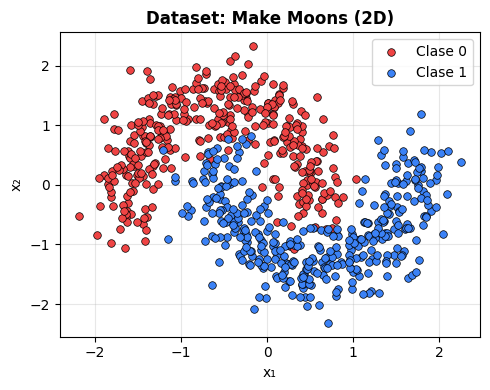

In [12]:
# ── Dataset Make Moons ────────────────────────────────────────────────
X_raw, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_raw    = StandardScaler().fit_transform(X_raw)   # Media=0, Std=1

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.25, random_state=42
)

# Determinar rango real para el grid adaptativo
x_min_data = float(X_raw.min()) - 0.1
x_max_data = float(X_raw.max()) + 0.1
print(f'Rango de datos: [{x_min_data:.2f}, {x_max_data:.2f}]')
print(f'Train: {X_train.shape}   Test: {X_test.shape}')

# Tensores PyTorch
X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_te = torch.tensor(X_test,  dtype=torch.float32)
y_te = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

# Visualizar dataset
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
           c='#EF4444', edgecolors='k', s=30, linewidths=0.5, label='Clase 0', zorder=3)
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
           c='#3B82F6', edgecolors='k', s=30, linewidths=0.5, label='Clase 1', zorder=3)
ax.set_title('Dataset: Make Moons (2D)', fontsize=12, fontweight='bold')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bloque4_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Modelo con grid adaptado al rango real de los datos ──────────────
# MEJORA: grid_range cubre todo el rango de datos → evita extrapolación lineal
torch.manual_seed(42)

def make_kan_model(widths, G=5, k=3, grid_range=(-2.5, 2.5)):
    """Crea KAN con grid adaptado al rango de los datos."""
    model = nn.Sequential()
    layers = []
    for i in range(len(widths) - 1):
        layers.append(KANLayer(widths[i], widths[i+1],
                               G=G, k=k, grid_range=grid_range))
    return nn.Sequential(*layers)

# Arquitectura: KAN [2 → 5 → 1]
model = KAN(widths=[2, 5, 1], G=5, k=3)
# Reasignar grid al rango real de los datos en cada capa
for layer in model.layers:
    grid_int  = torch.linspace(x_min_data, x_max_data, layer.G + 1)
    step      = (x_max_data - x_min_data) / layer.G
    left_ext  = grid_int[0]  - step * torch.arange(layer.k, 0, -1)
    right_ext = grid_int[-1] + step * torch.arange(1, layer.k + 1)
    layer.grid = torch.cat([left_ext, grid_int, right_ext])

optimizer  = torch.optim.Adam(model.parameters(), lr=5e-3)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=500)

EPOCHS     = 500
lambda_reg = 1e-4

history = {'epoch': [], 'loss': [], 'acc_train': [], 'acc_test': []}

print(f'{"Época":>6}  {"Loss":>10}  {"Acc Train":>10}  {"Acc Test":>10}')
print('─' * 44)

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    logits = model(X_tr)                          # (batch, 1)
    pred   = torch.sigmoid(logits)

    # Pérdida BCE + regularización L1 sobre coeficientes spline
    loss_bce = F.binary_cross_entropy(pred, y_tr)
    l1_reg   = sum(layer.coef.abs().mean() for layer in model.layers)
    loss     = loss_bce + lambda_reg * l1_reg

    loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 100 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            acc_tr = ((pred > 0.5).float() == y_tr).float().mean().item()
            acc_te = ((torch.sigmoid(model(X_te)) > 0.5).float() == y_te
                      ).float().mean().item()

        history['epoch'].append(epoch)
        history['loss'].append(loss.item())
        history['acc_train'].append(acc_tr)
        history['acc_test'].append(acc_te)
        print(f'{epoch:>6}  {loss.item():>10.4f}  '
              f'{acc_tr*100:>9.2f}%  {acc_te*100:>9.2f}%')

print(f'\n Accuracy final — Test: {history["acc_test"][-1]*100:.2f}%')

 Época        Loss   Acc Train    Acc Test
────────────────────────────────────────────
     1      1.3985      38.53%      35.20%
   100      0.4784      73.33%      74.40%
   200      0.1538      95.73%      98.00%
   300      0.0959      96.93%      97.20%
   400      0.0871      97.07%      97.20%
   500      0.0860      97.20%      97.20%

 Accuracy final — Test: 97.20%


---
##  Bloque 5 — Visualización de Resultados

Tres visualizaciones que demuestran lo que KAN aprendió:
1. **Frontera de decisión** — geometría aprendida en el espacio 2D
2. **φ(x) aprendida** — función de activación en una arista (invisible en MLP)
3. **Curvas de entrenamiento** — pérdida y precisión a lo largo de las épocas

C:\Users\Acer\AppData\Local\Temp\ipykernel_12812\370840638.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


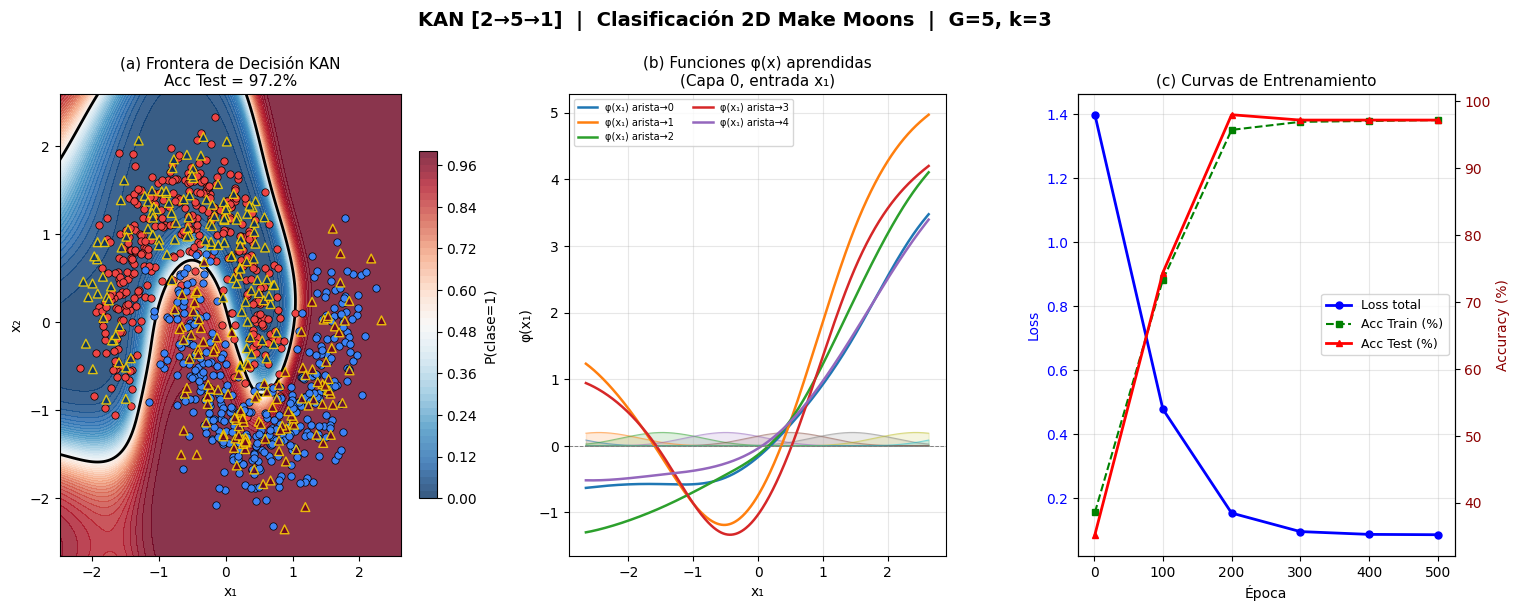


  Accuracy final — Train: 97.20%
  Accuracy final — Test:  97.20%


In [14]:
model.eval()

fig = plt.figure(figsize=(18, 6))
fig.suptitle('KAN [2→5→1]  |  Clasificación 2D Make Moons  |  G=5, k=3',
             fontsize=14, fontweight='bold', y=1.02)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── (a) FRONTERA DE DECISIÓN ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
h = 0.03
x1_min, x1_max = X_raw[:, 0].min() - 0.3, X_raw[:, 0].max() + 0.3
x2_min, x2_max = X_raw[:, 1].min() - 0.3, X_raw[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.arange(x1_min, x1_max, h),
                     np.arange(x2_min, x2_max, h))
grid_pts = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    Z = torch.sigmoid(model(grid_pts)).numpy().reshape(xx.shape)

cf = ax1.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.8)
ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
ax1.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
            c='#EF4444', edgecolors='k', s=28, linewidths=0.5, zorder=4)
ax1.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
            c='#3B82F6', edgecolors='k', s=28, linewidths=0.5, zorder=4)
ax1.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
            cmap='RdBu_r', edgecolors='gold', s=40, linewidths=1,
            marker='^', zorder=5, alpha=0.85)
plt.colorbar(cf, ax=ax1, fraction=0.046, label='P(clase=1)')
acc_final = history['acc_test'][-1] * 100
ax1.set_title(f'(a) Frontera de Decisión KAN\nAcc Test = {acc_final:.1f}%', fontsize=11)
ax1.set_xlabel('x₁'); ax1.set_ylabel('x₂')

# ── (b) φ(x) APRENDIDA — FUNCIÓN EN UNA ARISTA ───────────────────────
ax2 = fig.add_subplot(gs[1])
x_vals  = torch.linspace(x_min_data - 0.2, x_max_data + 0.2, 500)
layer0  = model.layers[0]

with torch.no_grad():
    bases_v = build_bspline_bases(x_vals, layer0.grid, layer0.k)
    colors_b = plt.cm.tab10(np.linspace(0, 1, bases_v.shape[1]))

    # Mostrar bases con relleno semi-transparente
    for idx in range(bases_v.shape[1]):
        ax2.fill_between(x_vals.numpy(), bases_v[:, idx].numpy() * 0.3,
                         alpha=0.15, color=colors_b[idx % 10])
        ax2.plot(x_vals.numpy(), bases_v[:, idx].numpy() * 0.3,
                 color=colors_b[idx % 10], linewidth=0.8, alpha=0.5)

    # Graficar φ(x) para las 5 conexiones de la entrada x₁
    for j in range(layer0.n_out):
        spline_fn = (layer0.coef[j, 0] * bases_v).sum(dim=1)
        silu_fn   = F.silu(x_vals)
        phi_fn    = layer0.w_b[j, 0] * silu_fn + layer0.w_s[j, 0] * spline_fn
        ax2.plot(x_vals.numpy(), phi_fn.numpy(),
                 linewidth=1.8, label=f'φ(x₁) arista→{j}')

ax2.axhline(0, color='gray', linestyle='--', linewidth=0.7)
ax2.set_title('(b) Funciones φ(x) aprendidas\n(Capa 0, entrada x₁)', fontsize=11)
ax2.set_xlabel('x₁'); ax2.set_ylabel('φ(x₁)')
ax2.legend(fontsize=7, ncol=2)
ax2.grid(alpha=0.3)

# ── (c) CURVAS DE ENTRENAMIENTO ───────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3r = ax3.twinx()

ax3.plot(history['epoch'], history['loss'],
         'b-o', markersize=5, linewidth=2, label='Loss total')
ax3r.plot(history['epoch'], [a * 100 for a in history['acc_train']],
          'g--s', markersize=5, linewidth=1.5, label='Acc Train (%)')
ax3r.plot(history['epoch'], [a * 100 for a in history['acc_test']],
          'r-^', markersize=5, linewidth=2, label='Acc Test (%)')

ax3.set_title('(c) Curvas de Entrenamiento', fontsize=11)
ax3.set_xlabel('Época')
ax3.set_ylabel('Loss', color='blue')
ax3r.set_ylabel('Accuracy (%)', color='darkred')
ax3.tick_params(axis='y', labelcolor='blue')
ax3r.tick_params(axis='y', labelcolor='darkred')

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3r.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bloque5_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"="*45}')
print(f'  Accuracy final — Train: {history["acc_train"][-1]*100:.2f}%')
print(f'  Accuracy final — Test:  {history["acc_test"][-1]*100:.2f}%')
print(f'{"="*45}')

---
## Resumen: Fórmulas implementadas

| Fórmula | Nombre | Implementado en |
|---------|--------|-----------------|
| $B_{i,0}(x) = \mathbf{1}[t_i \leq x < t_{i+1}]$ | Caso base spline | `build_bspline_bases()` |
| $B_{i,k}(x) = \frac{x-t_i}{t_{i+k}-t_i}B_{i,k-1} + \frac{t_{i+k+1}-x}{t_{i+k+1}-t_{i+1}}B_{i+1,k-1}$ | Recursión de Boor | `build_bspline_bases()` |
| $\phi(x) = w_b \cdot \text{SiLU}(x) + w_s \cdot \sum_i c_i B_{i,k}(x)$ | Activación aprendible | `KANLayer._phi()` |
| $x_{\ell+1,j} = \sum_i \phi_{j,i}(x_{\ell,i})$ | Forward pass | `KANLayer.forward()` |
| $N_{\text{params}} = n_{\text{in}} \times n_{\text{out}} \times (G+k+2)$ | Conteo parámetros | `KAN.count_params()` |
| $\mathcal{L} = \mathcal{L}_{\text{BCE}} + \lambda\,\|\phi\|_1$ | Pérdida regularizada | Bucle entrenamiento |

---

##  KAN vs MLP — Alcances y Limitaciones

| Aspecto | KAN  | MLP  |
|---------|--------|--------|
| Interpretabilidad | Alta — φ(x) visible y exportable | Baja — caja negra |
| Convergencia | $O(N^{-4})$ splines cúbicos | $O(N^{-\alpha/n})$ — crece con dimensión |
| Precisión con pocos params | Alta en funciones suaves | Requiere más neuronas |
| Velocidad de entrenamiento | **10-100× más lento** | Más rápido (ops matriciales GPU) |
| Escalabilidad CV/NLP | **Limitada** (sin equiv. CNN/BERT) | Alta |
| Sensibilidad al grid G | Alta (hiperparámetro crítico) | No aplica |
| Madurez del ecosistema | Experimental (2024, pykan) | Décadas de optimización |